In [1]:
import pandas as pd
df = pd.read_csv('c:/data/ozone/ozone2.csv')
df.head()

,Month,Day,Solar.R,Wind,Temp,Ozone,Result
0,5,1,190.000000,7.4,67,41,0
1,5,2,118.000000,8.0,72,36,0
2,5,3,149.000000,12.6,74,12,0
3,5,4,313.000000,11.5,62,18,0
4,5,5,185.931507,14.3,56,42,1


In [2]:
df['Result'].value_counts()

Result
1    81
0    72
Name: count, dtype: int64

In [3]:
cols=['Solar.R', 'Wind', 'Temp']
X = df[cols]
y = df['Result']

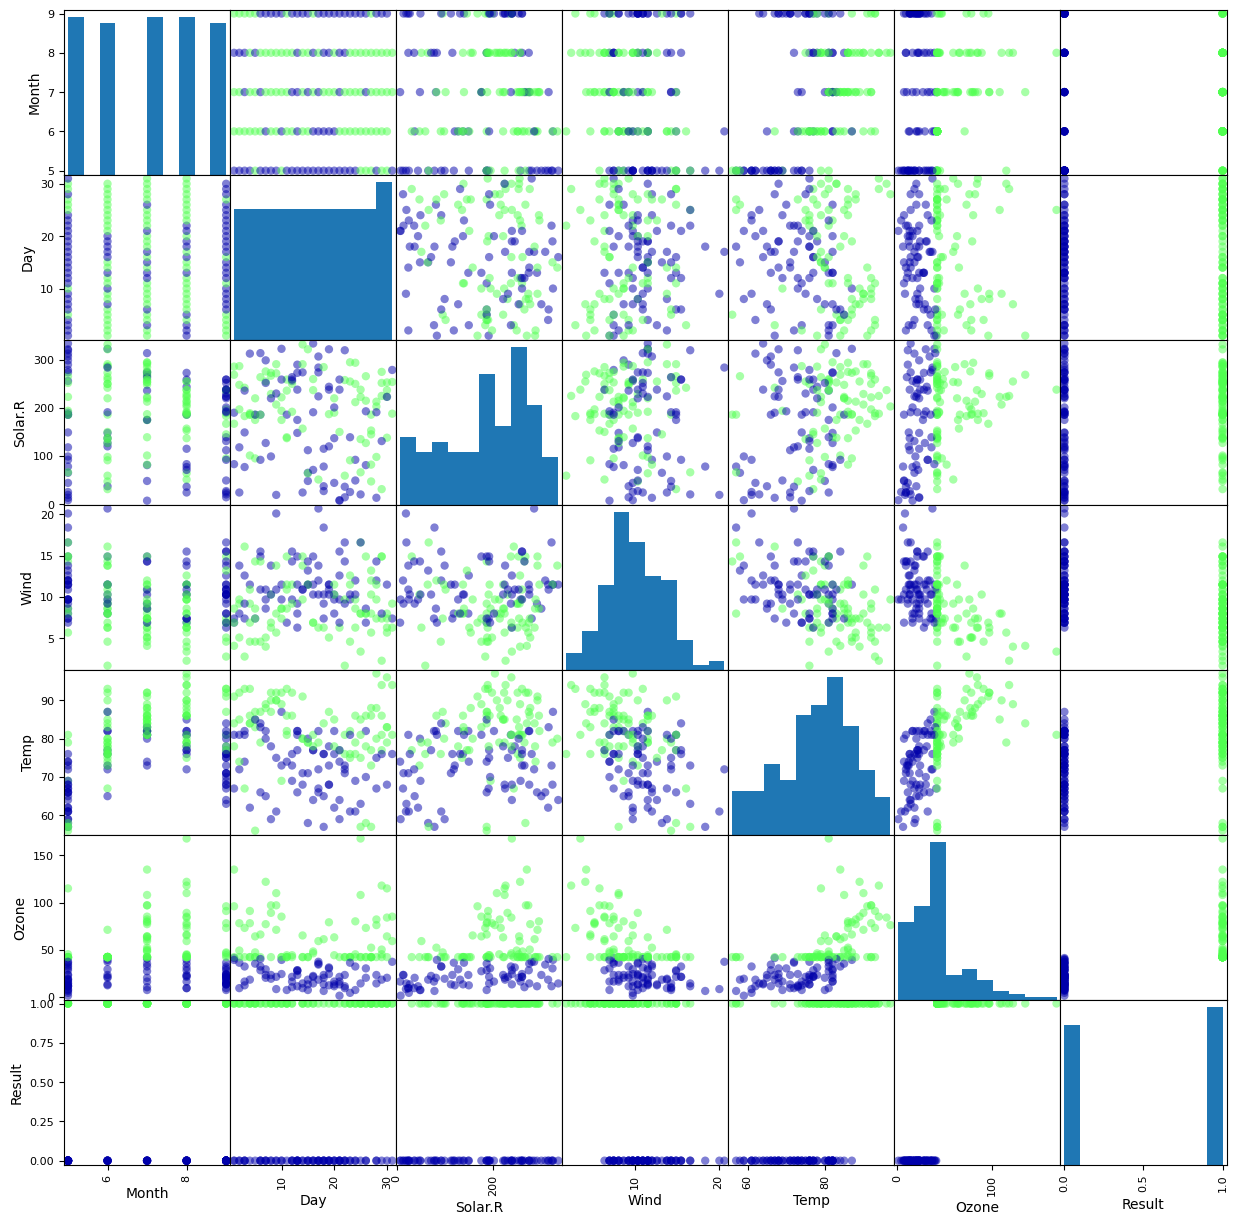

In [4]:
import mglearn
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(df, c=y, figsize=(15,15), marker='o', cmap=mglearn.cm3)
plt.show()

In [5]:
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=cols)
y_samp = pd.DataFrame(data=y_sample, columns=['Result'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp['Result'].value_counts()

Result
0    72
1    72
Name: count, dtype: int64

In [6]:
X = X_samp[cols]
y = y_samp['Result']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=10)

In [9]:
from sklearn.svm import SVC
model = SVC(random_state=10)
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
import numpy as np
pred=model.predict(X_test)
print('학습용:',model.score(X_train, y_train))
print('검증용:',model.score(X_test, y_test))

학습용: 0.6347826086956522
검증용: 0.6896551724137931


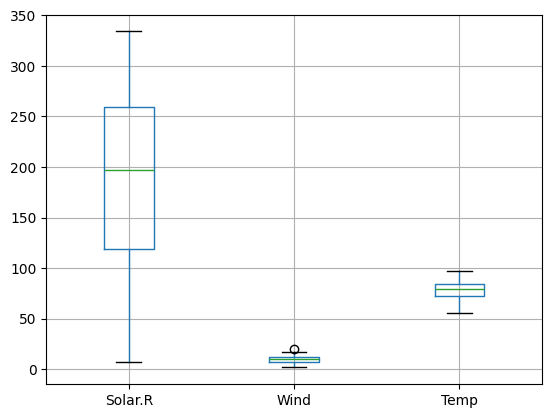

In [11]:
X_train.boxplot()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(X_train)
X_train_scaled = pd.DataFrame(ss.transform(X_train))
X_test_scaled = pd.DataFrame(ss.transform(X_test))

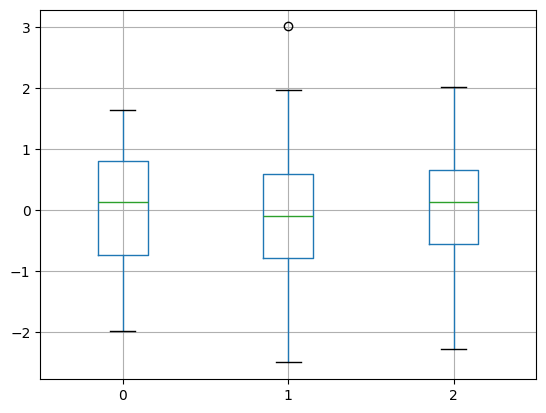

In [14]:
X_train_scaled.boxplot()
plt.show()

In [15]:
model = SVC(random_state=10)
model.fit(X_train_scaled, y_train)
print('학습용:',model.score(X_train_scaled, y_train))
print('검증용:',model.score(X_test_scaled, y_test))

학습용: 0.7391304347826086
검증용: 0.8620689655172413


In [20]:
import numpy as np
train_rate = []
test_rate = []
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
g_values = [0.0001, 0.001, 0.01, 0.1]
for n in c_values:
    for g in g_values:
        model = SVC(C=n, gamma=g, random_state=10)
        model.fit(X_train_scaled, y_train)
        train_rate.append([n,g,model.score(X_train_scaled, y_train)])
        test_rate.append([n,g,model.score(X_test_scaled, y_test)])

train_arr = np.array(train_rate)
test_arr = np.array(test_rate)
max_rate = np.max(test_arr[:,2])
idx = np.where(test_arr[:,2]==max_rate)[0][0]
print(idx)

15


In [35]:
test_arr

array([[1.00000000e-03, 1.00000000e-04, 4.82758621e-01],
       [1.00000000e-03, 1.00000000e-03, 4.82758621e-01],
       [1.00000000e-03, 1.00000000e-02, 4.82758621e-01],
       [1.00000000e-03, 1.00000000e-01, 4.82758621e-01],
       [1.00000000e-02, 1.00000000e-04, 4.82758621e-01],
       [1.00000000e-02, 1.00000000e-03, 4.82758621e-01],
       [1.00000000e-02, 1.00000000e-02, 4.82758621e-01],
       [1.00000000e-02, 1.00000000e-01, 4.82758621e-01],
       [1.00000000e-01, 1.00000000e-04, 4.82758621e-01],
       [1.00000000e-01, 1.00000000e-03, 4.82758621e-01],
       [1.00000000e-01, 1.00000000e-02, 4.82758621e-01],
       [1.00000000e-01, 1.00000000e-01, 8.27586207e-01],
       [1.00000000e+00, 1.00000000e-04, 4.82758621e-01],
       [1.00000000e+00, 1.00000000e-03, 4.82758621e-01],
       [1.00000000e+00, 1.00000000e-02, 7.58620690e-01],
       [1.00000000e+00, 1.00000000e-01, 8.62068966e-01],
       [1.00000000e+01, 1.00000000e-04, 4.82758621e-01],
       [1.00000000e+01, 1.00000

In [21]:
print('최적의 c:', test_rate[idx][0])
print('최적의 gamma:', test_rate[idx][1])
print('최적의 정확도:', test_rate[idx][2])

최적의 c: 1
최적의 gamma: 0.1
최적의 정확도: 0.8620689655172413


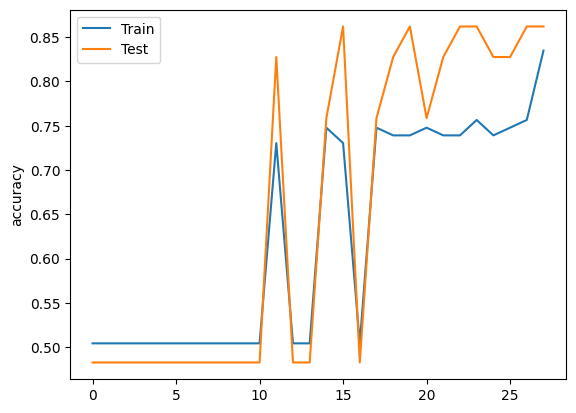

In [22]:
plt.plot(range(len(train_rate)), train_arr[:,2], label='Train')
plt.plot(range(len(test_rate)), test_arr[:,2], label='Test')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [29]:
model = SVC(C=1, gamma=0.1, random_state=10)
model.fit(X_train_scaled, y_train)
print('학습용:',model.score(X_train_scaled, y_train))
print('검증용:',model.score(X_test_scaled, y_test))

학습용: 0.7304347826086957
검증용: 0.8620689655172413


In [30]:
from sklearn.metrics import confusion_matrix
pred=model.predict(X_test_scaled)
confusion_matrix(y_test, pred)

array([[13,  1],
       [ 3, 12]])

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.81      0.93      0.87        14
           1       0.92      0.80      0.86        15

    accuracy                           0.86        29
   macro avg       0.87      0.86      0.86        29
weighted avg       0.87      0.86      0.86        29

